#P8 - GP Extra: Regresión para toda la serie histórica

Nombre:

NIP:

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from datetime import datetime, timedelta
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    ExpSineSquared,
    RationalQuadratic,
    WhiteKernel,
)

%matplotlib inline

# Funciones auxiliares de carga y visualizacion



```
def parse_multiple_files(file_list, contaminant_code)
# Read multiple files and return a data frame with the data from all available stations for the selected contaminant

def plot_station_time_series(df, station_id=None, title=None)
# plot data from the dataframe


```



In [ ]:
def parse_single_file(file_path, contaminant_code):
    df = pd.read_csv(file_path, sep=';', encoding='latin1', dtype={'ESTACION': str})
    df = df[df['MAGNITUD'] == contaminant_code]

    records = []

    for _, row in df.iterrows():
        year = int(row['ANO'])
        month = int(row['MES'])
        station = row['ESTACION'].zfill(2)

        for day in range(1, 32):
            day_str = f"{day:02d}"
            value_col = f"D{day_str}"
            valid_col = f"V{day_str}"

            if valid_col in row and row[valid_col] == 'V':
                try:
                    value = float(row[value_col])
                    date = datetime(year, month, day)
                    records.append((station, date, value))
                except Exception:
                    continue

    df_time = pd.DataFrame(records, columns=["station", "date", "value"])

    # Add days-since-2000 index
    base_date = datetime(2005, 1, 1)
    df_time["INDEX"] = (df_time["date"] - base_date).dt.days

    # Pivot by station
    pivot_df = df_time.pivot_table(index="date", columns="station", values="value", aggfunc='mean')

    # Add INDEX to pivoted data
    pivot_df = pivot_df.merge(df_time[["date", "INDEX"]].drop_duplicates(), on="date", how="left")
    pivot_df.set_index("INDEX", inplace=True)
    pivot_df.sort_index(inplace=True)

    return pivot_df

def parse_multiple_files(file_list, contaminant_code):
    combined = []

    for file in file_list:
        #print(f"Processing: {file}")
        df = parse_single_file(file, contaminant_code)
        combined.append(df)

    # Combine all years
    final_df = pd.concat(combined)
    final_df = final_df[~final_df.index.duplicated(keep='first')]  # Remove duplicate INDEX values if any
    final_df.sort_index(inplace=True)

    return final_df

def plot_station_time_series(df, station_id, title=None):
    if station_id not in df.columns:
        print(f"Station {station_id} not found in the data.")
        return

    series = df[station_id].dropna()

    plt.figure(figsize=(14, 5))
    plt.plot(series.index, series.values, label=f"Station {station_id}", color='teal')
    plt.title(title or f"Air Quality Time Series – Station {station_id}")
    plt.xlabel("Days since 01-01-2000 (INDEX)")
    plt.ylabel("Pollutant Level")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_station_time_series(df, station_id=None, title=None):
    plt.figure(figsize=(14, 6))

    # Exclude non-station columns if they exist (like 'date')
    station_columns = [col for col in df.columns if col != 'date']

    if station_id:
        if station_id not in station_columns:
            print(f"Station {station_id} not found in the data.")
            return
        series = df[station_id].dropna()
        plt.plot(series.index, series.values, label=f"Station {station_id}")
    else:
        for col in station_columns:
            series = df[col].dropna()
            plt.plot(series.index, series.values, label=f"Station {col}", alpha=0.7)

    plt.title(title or (
        f"Air Quality Time Series – Station {station_id}" if station_id else "Air Quality – All Stations"
    ))
    plt.xlabel("Days since 01-01-2000 (INDEX)")
    plt.ylabel("Pollutant Level")
    plt.grid(True)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.02))
    plt.tight_layout()
    plt.show()

def get_station_series(final_data, station_id):
    """
    Returns two 1D numpy arrays: X (INDEX) and y (measurements)
    for a given station from the final_data DataFrame.

    Parameters:
    - final_data: pd.DataFrame with INDEX as index and station columns
    - station_id: str, the station code to retrieve

    Returns:
    - X: numpy array of INDEX values
    - y: numpy array of measurement values
    """
    if station_id not in final_data.columns:
        raise ValueError(f"Station '{station_id}' not found in data.")

    series = final_data[station_id].dropna()
    seriesNan = final_data[station_id]

    X = series.index.to_numpy()
    y = series.values

    X_nan = seriesNan.index.to_numpy()
    y_nan = seriesNan.values

    X_nan = X[np.isnan(y_nan)]

    return X, y, X_nan

## a) Leer los ficheros y cargar el dataframe para un contaminante.

Hay disponibles 18 contaminantes (ver contaminant_name_to_code para la lista completa):

Os recomendamos trabajar con estos cuatro:_ `O3`, `N2`, `CO` y `NOx`. Algunas observaciones:


1. Cada indicador tiene medidas solo en algunos días. Esto significa que tendréis que <br>
ajustar el rango de predicción en función del indicador que elijais.

2. Algunos indicadores tienen huecos en la serie temporal, por lo que se puede predecir <br>
en los huecos. También podéis crear los huecos vosotros eliminando datos.

3. Observar los datos y proponer kernels para ajustar la serie temporal.
<!-- <br> Recordad que una suma se puede interpretar como un OR y una multiplicación como un AND. Podéis ver un ejemplo para CO2 [aqui](https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_co2.html). -->

4. Podéis subsamplear los datos. Revisar la complejidad que tiene el GP a nivel computacional.

In [154]:
# List of files containing the data

file_path = "datosDiariosPorAnio/"

file_list = {
    "datos01.csv", "datos02.csv", "datos03.csv", "datos04.csv",
    "datos05.csv", "datos06.csv", "datos07.csv", "datos08.csv",
    "datos09.csv", "datos10.csv", "datos11.csv", "datos12.csv",
    "datos13.csv", "datos14.csv", "datos15.csv",
    "datos201612.csv", "datos17.csv",
    "datos201812.CSV", "datos201912.csv", "datos202012.csv",
    "datos202112.csv", "datos202212.csv",
    "datos202312.csv", "datos202412.csv", "datos202503.csv",
}

file_list = [file_path + file for file in file_list]

# Code for each possible contaminant
contaminant_name_to_code = {
    "SO2": 1,
    "CO": 6,
    "NO": 7,
    "NO2": 8,
    "PM10": 10,
    "NOx": 12,
    "O3": 14,
    "TOL": 20,
    "BEN": 30,
    "EBE": 35
}


contaminant="NOx"
final_data = parse_multiple_files(file_list, contaminant_name_to_code[contaminant])

final_data.to_csv('dataframe'+contaminant+'.csv', index=False)


Definamos una serie de funciones auxiliares para analizar los datos.

In [201]:
def summarize_station_data(df):
    """
    Summarizes data for each station in the dataframe.
    Returns a DataFrame with:
    - Number of NAs
    - Average
    - Max
    - Min
    - 95th percentile (q095)
    - 1th percentile (q005)
    """
    summary = []
    # Exclude non-station columns if any (like 'date')
    station_columns = [col for col in df.columns if col != 'date']
    for station in station_columns:
        series = df[station].dropna()
        summary.append({
            "station": station,
            "num_NA": df[station].isna().sum(),
            "average": series.mean() if not series.empty else np.nan,
            "max": series.max() if not series.empty else np.nan,
            "min": series.min() if not series.empty else np.nan,
            "q005": series.quantile(0.05) if not series.empty else np.nan,
            "q095": series.quantile(0.95) if not series.empty else np.nan,
        })
    return pd.DataFrame(summary)

def get_station_monthly_data(df, station_id):
    """
    Summarizes data for a given station in the dataframe by months.
    Returns a DataFrame with:
    - Number of NAs
    - Average
    - Max
    - Min
    - 95th percentile (q095)
    - 1th percentile (q005)
    for each month of the year.
    """
    # Ensure 'date' is datetime
    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])

    month_summary = pd.DataFrame(columns=[
        "num_NA", "average", "max", "min", "q005", "q095"
    ], index=range(1, 13))

    for month in range(1, 13):
        month_data = df[df['date'].dt.month == month][station_id]
        month_summary.loc[month] = [
            month_data.isna().sum(),
            month_data.mean(),
            month_data.max(),
            month_data.min(),
            month_data.quantile(0.05),
            month_data.quantile(0.95),
        ]

    return month_summary

def get_station_dayofyear_data(df, station_id):
    """
    Summarizes data for a given station in the dataframe by day of the year (1-366).
    Returns a DataFrame with:
    - Number of NAs
    - Average
    - Max
    - Min
    - 95th percentile (q095)
    - 1th percentile (q005)
    for each day of the year.
    """
    # Ensure 'date' is datetime
    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])

    day_summary = pd.DataFrame(columns=[
        "num_NA", "average", "max", "min", "q005", "q095"
    ], index=range(1, 367))

    for day in range(1, 367):
        day_data = df[df['date'].dt.dayofyear == day][station_id]
        day_summary.loc[day] = [
            day_data.isna().sum(),
            day_data.mean(),
            day_data.max(),
            day_data.min(),
            day_data.quantile(0.05),
            day_data.quantile(0.95),
        ]

    return day_summary

def get_station_yearly_data(df, station_id):
    """
    Summarizes data for a given station in the dataframe by year.
    Returns a DataFrame with:
    - Number of NAs
    - Average
    - Max
    - Min
    - 95th percentile (q095)
    - 1th percentile (q005)
    for each year.
    """
    # Ensure 'date' is datetime
    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])

    years = df['date'].dt.year.unique()
    year_summary = pd.DataFrame(columns=[
        "num_NA", "average", "max", "min", "q005", "q095"
    ], index=sorted(years))

    for year in years:
        year_data = df[df['date'].dt.year == year][station_id]
        year_summary.loc[year] = [
            year_data.isna().sum(),
            year_data.mean(),
            year_data.max(),
            year_data.min(),
            year_data.quantile(0.05),
            year_data.quantile(0.95),
        ]

    return year_summary

def histogram_station_data(df, station_id, bins=50):
    """
    Plots a histogram of the data for a given station.
    """
    if station_id not in df.columns:
        print(f"Station {station_id} not found in the data.")
        return

    series = df[station_id].dropna()

    plt.figure(figsize=(14, 5))
    plt.hist(series, bins=bins, color='teal', alpha=0.7)
    plt.title(f"Histogram of Air Quality Data – Station {station_id}")
    plt.xlabel("Pollutant Level")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_gp(
    gp, X, y, trained_mask=None, title=None, future_pred_length=0, X_nan=None, focus=None
):
    """
    Plots the Gaussian Process regression results.
    - Adds future predictions as a violet line.
    - Plots predictions where X is NaN in y as violet points.
    - If focus=(x_inf, x_sup) is provided, only plots that x-range (including training points, predictions, and NaN predictions).
    """
    X = X.reshape(-1, 1)
    y = y.reshape(-1, 1)

    # Focus range
    if focus is not None:
        x_inf, x_sup = focus
        # Mask for X/y in focus
        focus_X_mask = (X.flatten() >= x_inf) & (X.flatten() <= x_sup)
    else:
        # If no focus, set bounds to cover all data + future
        x_inf, x_sup = X.min(), X.max() + future_pred_length
        focus_X_mask = np.ones_like(X.flatten(), dtype=bool)

    # Create a grid of points to predict (within the focus range or full range + future)
    x_pred = np.linspace(x_inf, x_sup, 1000).reshape(-1, 1)
    y_pred, sigma = gp.predict(x_pred, return_std=True)

    plt.figure(figsize=(14, 5))

    # Plot the observations (non-NaN y values within focus)
    non_nan_mask_flat = ~np.isnan(y.flatten())
    obs_focus_mask = non_nan_mask_flat & focus_X_mask
    plt.plot(
        X.flatten()[obs_focus_mask], y.flatten()[obs_focus_mask],
        '.', markersize=3, label='Observations', alpha=0.2, color='teal'
    )

    # Plot the training points (only those in focus)
    if trained_mask is not None:
        # Ensure trained_mask indices are valid for the non-NaN subset used for training
        X_non_nan = X[non_nan_mask_flat]
        y_non_nan = y[non_nan_mask_flat]
        if len(X_non_nan) > 0:
            valid_trained_indices = [idx for idx in trained_mask if 0 <= idx < len(X_non_nan)]
            if valid_trained_indices:
                X_train_points = X_non_nan[valid_trained_indices]
                y_train_points = y_non_nan[valid_trained_indices]

                # Apply focus mask to training points
                train_focus_mask = (X_train_points.flatten() >= x_inf) & (X_train_points.flatten() <= x_sup)
                if np.any(train_focus_mask):
                    plt.plot(
                        X_train_points.flatten()[train_focus_mask], y_train_points.flatten()[train_focus_mask],
                        '.', markersize=10, label='Training Points', alpha=0.8, color="red"
                    )

    # Plot the predictions for the range (in focus)
    plt.plot(
        x_pred.flatten(), y_pred.flatten(), 'b-', label='Prediction'
    )
    plt.fill_between(
        x_pred.flatten(),
        (y_pred - 1.96 * sigma).flatten(),
        (y_pred + 1.96 * sigma).flatten(),
        alpha=0.2, color='blue', label='95% confidence interval'
    )

    # Plot the future predictions as a violet line (only if no focus is set)
    if future_pred_length > 0 and focus is None:
        actual_X_max = X[non_nan_mask_flat].max() if np.any(non_nan_mask_flat) else X.max()
        future_mask_pred = x_pred.flatten() > actual_X_max
        if np.any(future_mask_pred):
            plt.plot(
                x_pred.flatten()[future_mask_pred], y_pred.flatten()[future_mask_pred],
                color='violet', linestyle='--', label='Future Prediction'
            )

    # Plot predictions where y is NaN as violet points (in focus)
    if X_nan is not None and len(X_nan) > 0:
        X_nan = X_nan.reshape(-1, 1)
        # Apply focus mask to X_nan
        nan_focus_mask = (X_nan.flatten() >= x_inf) & (X_nan.flatten() <= x_sup)
        X_nan_focused = X_nan[nan_focus_mask]

        if len(X_nan_focused) > 0:
            print(f"Predicting {len(X_nan_focused)} NaN points within focus range")
            y_nan_pred, _ = gp.predict(X_nan_focused, return_std=True)
            plt.plot(
                X_nan_focused, y_nan_pred, 'o', color='violet', markersize=5, label='Predicted NaN', alpha=0.7
            )

    plt.title(title or "Gaussian Process Regression")
    plt.xlabel("Days since 01-01-2000 (INDEX)")
    plt.ylabel("Pollutant Level")
    plt.grid(True)
    plt.legend()
    # Set x-limits explicitly to match focus or full range + future
    plt.xlim(x_inf, x_sup)
    plt.tight_layout()
    plt.show()

def plot_dayofyear_summary(day_summary, station_id):
    """
    Plots the day-of-year summary statistics for a station.
    """
    # Ensure columns are numeric
    for col in ["average", "q005", "q095"]:
        day_summary[col] = pd.to_numeric(day_summary[col], errors="coerce")

    plt.figure(figsize=(14, 6))
    plt.plot(day_summary.index, day_summary["average"], label="Average")
    plt.fill_between(
        day_summary.index,
        day_summary["q005"],
        day_summary["q095"],
        alpha=0.2,
        label="1st-95th percentile"
    )
    plt.title(f"Day-of-Year Summary for Station {station_id}")
    plt.xlabel("Day of Year")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_monthly_summary(month_summary, station_id):
    """
    Plots the monthly summary statistics for a station.
    """
    # Ensure columns are numeric
    for col in ["average", "q005", "q095"]:
        month_summary[col] = pd.to_numeric(month_summary[col], errors="coerce")

    plt.figure(figsize=(12, 6))
    plt.plot(month_summary.index, month_summary["average"], marker='o', label="Average")
    plt.fill_between(month_summary.index, month_summary["q005"], month_summary["q095"], alpha=0.2, label="1st-95th percentile")
    plt.title(f"Monthly Summary for Station {station_id}")
    plt.xlabel("Month")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_yearly_summary(year_summary, station_id):
    """
    Plots the yearly summary statistics for a station.
    """
    # Ensure columns are numeric
    for col in ["average", "q005", "q095"]:
        year_summary[col] = pd.to_numeric(year_summary[col], errors="coerce")

    plt.figure(figsize=(10, 6))
    plt.plot(year_summary.index, year_summary["average"], marker='o', label="Average")
    plt.fill_between(year_summary.index, year_summary["q005"], year_summary["q095"], alpha=0.2, label="1st-95th percentile")
    plt.title(f"Yearly Summary for Station {station_id}")
    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

   station  num_NA     average     max  min  q005    q095
0       04     315  111.329298   849.0  4.0  21.0  316.00
1       08     605  110.884171   851.0  7.0  26.0  270.00
2       11      91   91.199931   749.0  5.0  20.0  234.00
3       16     132   70.855384   595.0  3.0  15.0  196.00
4       17    1597  100.582814   975.0  6.0  18.0  342.70
5       18     148   74.167358   713.0  5.0  15.0  227.00
6       24     158   42.348373   467.0  2.0   6.0  135.00
7       27     763   69.746061   647.0  4.0  16.0  183.00
8       35     213   90.670770   802.0  5.0  22.0  238.50
9       36      73   80.198035   669.0  5.0  17.0  215.00
10      38      63   97.815546  1031.0  5.0  20.0  263.00
11      39     186   89.640426   855.0  4.0  16.0  281.00
12      40      59   68.603651   652.0  6.0  18.0  183.00
13      47    3305   62.504258   461.0  4.0  12.0  189.10
14      48    3453   55.590020   429.0  4.0  13.0  146.50
15      49    3317   43.009261   421.0  3.0  10.0  129.00
16      50    

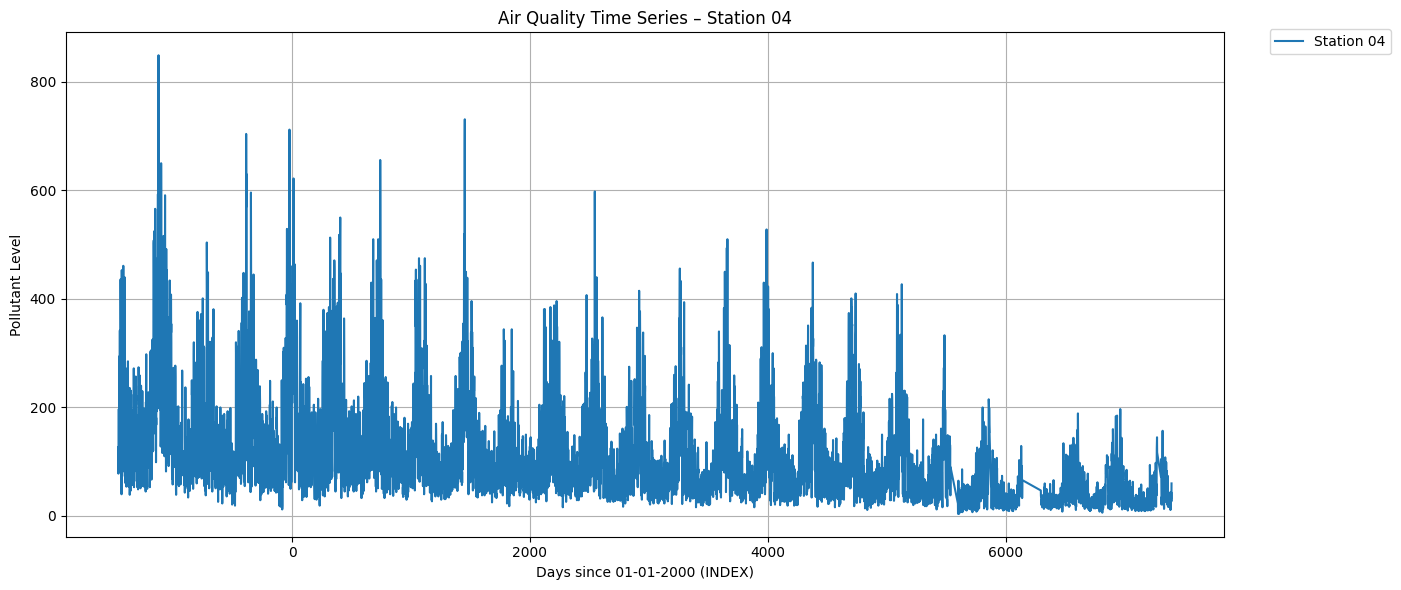

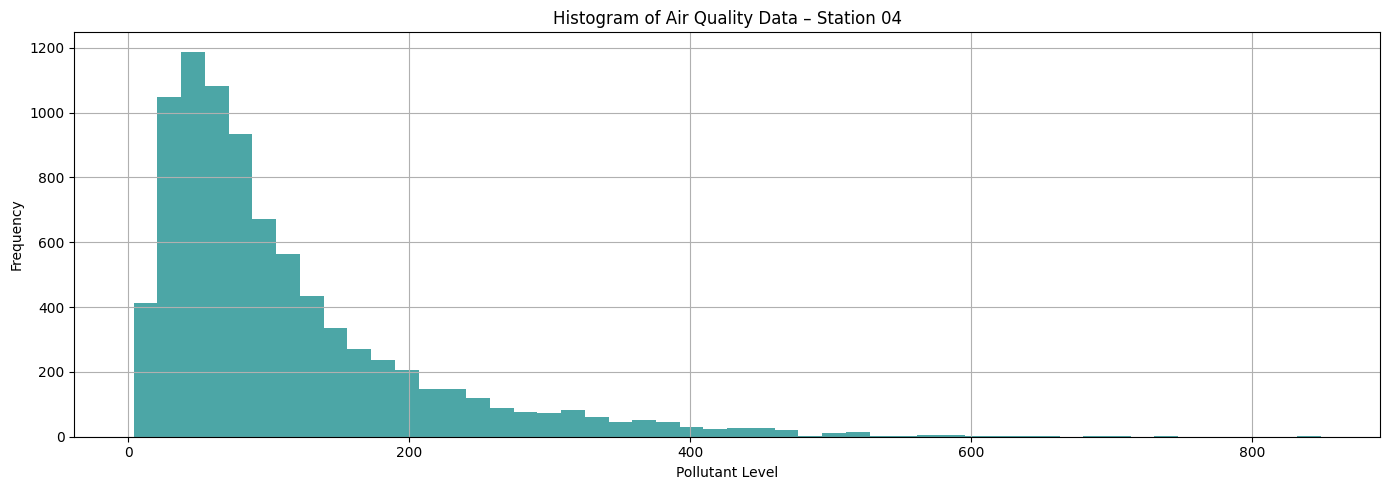

In [156]:

# Check the data statistics  and plot the time series
summary_table = summarize_station_data(final_data)
print(summary_table)

# Pick a station with data
station_id = "04"
plot_station_time_series(final_data, station_id)

# Plot the histogram of the data for the selected station
histogram_station_data(final_data, station_id)

# Plot the monthly data for the selected station
monthly_data = get_station_monthly_data(final_data, station_id)




Aquí podemos observar:
- De forma periódica hay picos en la polución que provocan cambios bruscos.
- Sin embargo, con el $95\%$, los valores son menores a 550.
- La estación tiene 1594 días sin predicciones para esta covariable.

Veamos los comportamientos por meses, días del año y años

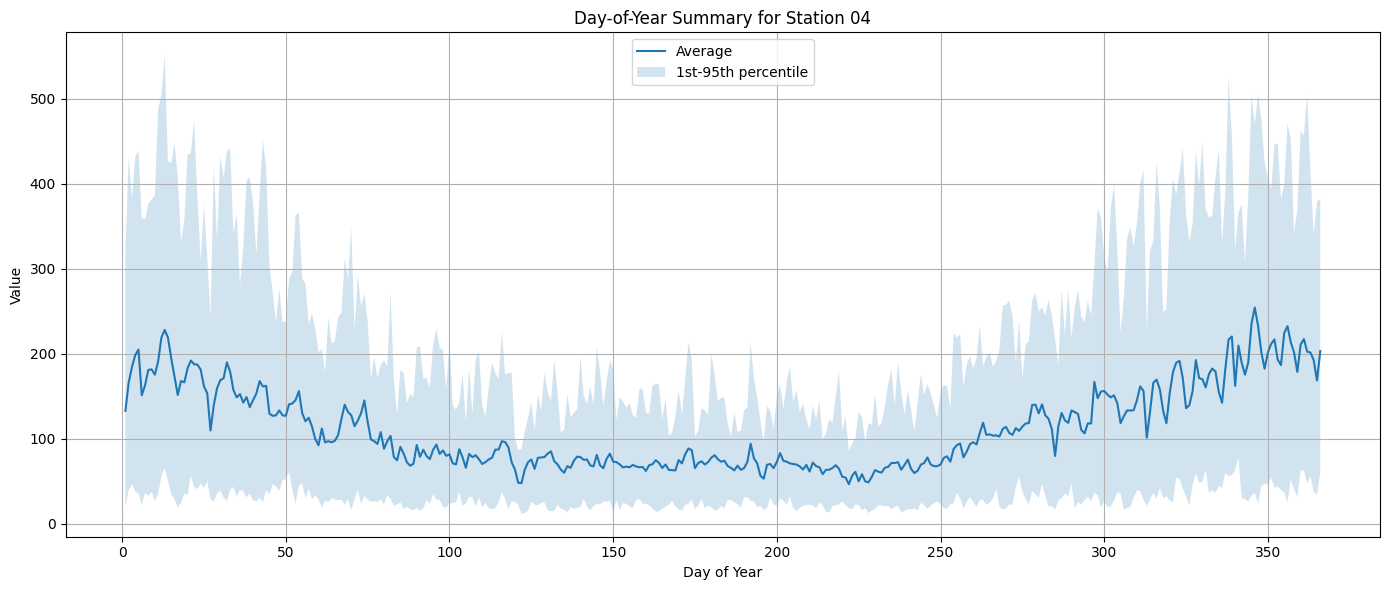

In [157]:
days_summary = get_station_dayofyear_data(final_data, station_id)
plot_dayofyear_summary(days_summary, station_id)

Aquí podemos ver que:
- Hay una tendencia periódica, tendiendo ha mayores contaminaciones a finales y principios de año.
- En los meses de verano, la contaminación es menor.
- Esto se debe a que en invierno, hay más emisiones de óxidos nitrogenados debido al uso de sistemas de calefacción y emisiones de tráfico

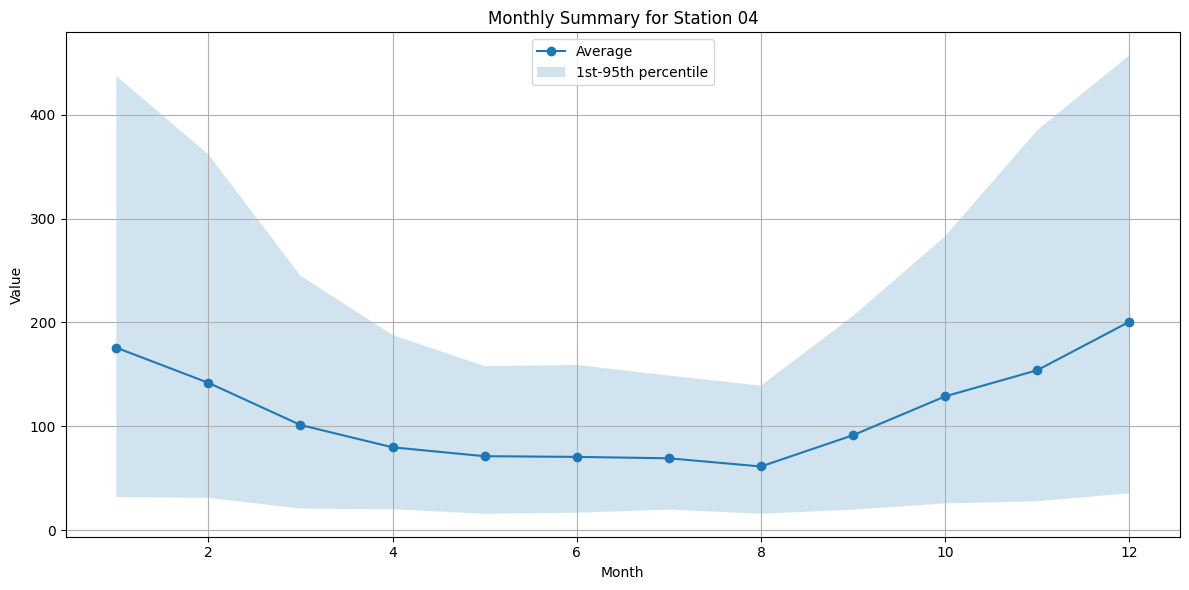

In [158]:
monthly_data = get_station_monthly_data(final_data, station_id)
plot_monthly_summary(monthly_data, station_id)

Finalmente, realizamos un estudio por años:

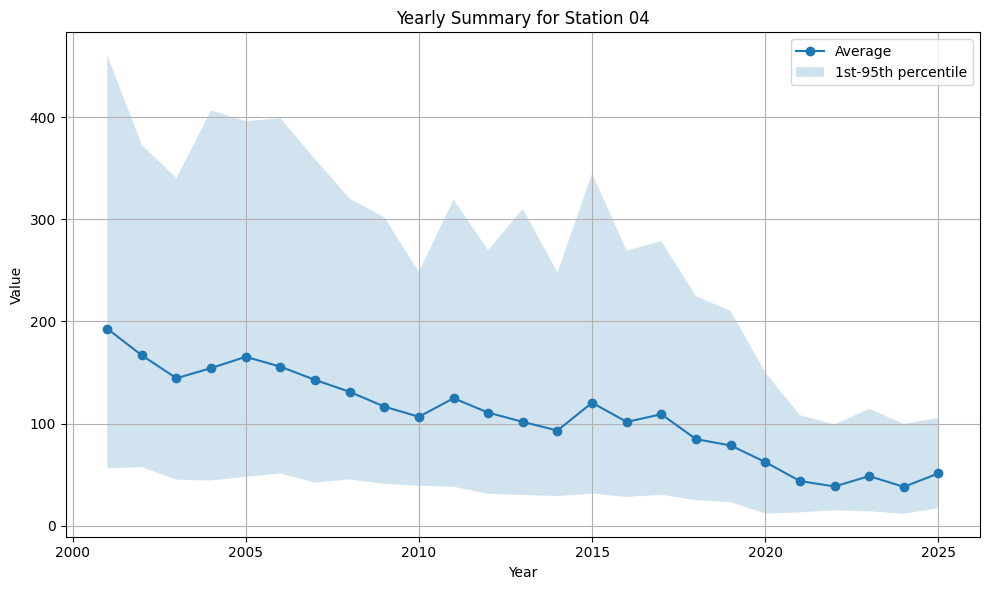

In [159]:
year_summary = get_station_yearly_data(final_data, station_id)
plot_yearly_summary(year_summary, station_id)

Aquí podemos ver que:
- Se detecta una tendencia decreciente en la contaminación del aire.
- La variabilidad de las mediciones también se reduce bastante, teniendo menos días de extremos superiores.

# b) Diseño del kernel y proceso Gaussiano

En los datos presentes se observan:
- Una tendencia en el tiempo periódica, por lo que se va a introducir una componente periódica
- Ruido, por lo que se va a añadir una componente de ruido.
- Valores atípicos muy cambiantes, por lo que se va a utilizar un Kernel `RationalQuadratic`

In [187]:
# dataset a ajustar por Gaussian Process:
X, y, X_nan = get_station_series(final_data, station_id)


trained_mask = list(range(0, len(X), 50))  # Mask for training data

X_subset = X[trained_mask]  # Subset for plotting
y_subset = y[trained_mask]


kernel = ConstantKernel(2)*RationalQuadratic(length_scale=40, alpha=1.0) \
       +  WhiteKernel(noise_level=0.3) +  \
        ExpSineSquared(length_scale=10.0, periodicity=365.0, periodicity_bounds="fixed")

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=0.1, normalize_y=True, random_state=10, optimizer=None)
gp.fit(X_subset.reshape(-1, 1), y_subset)

gp.kernel_

1.41**2 * RationalQuadratic(alpha=1, length_scale=40) + WhiteKernel(noise_level=0.3) + ExpSineSquared(length_scale=10, periodicity=365)

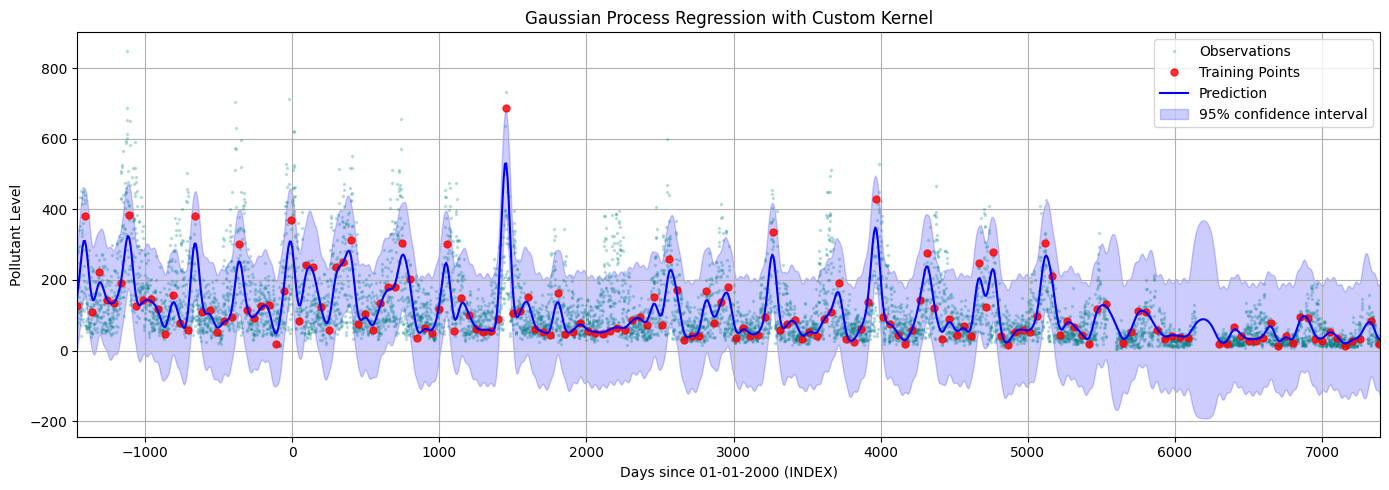

In [202]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process Regression with Custom Kernel")

Predecimos los valores donde hay valores NAN.

Predicting 287 NaN points within focus range


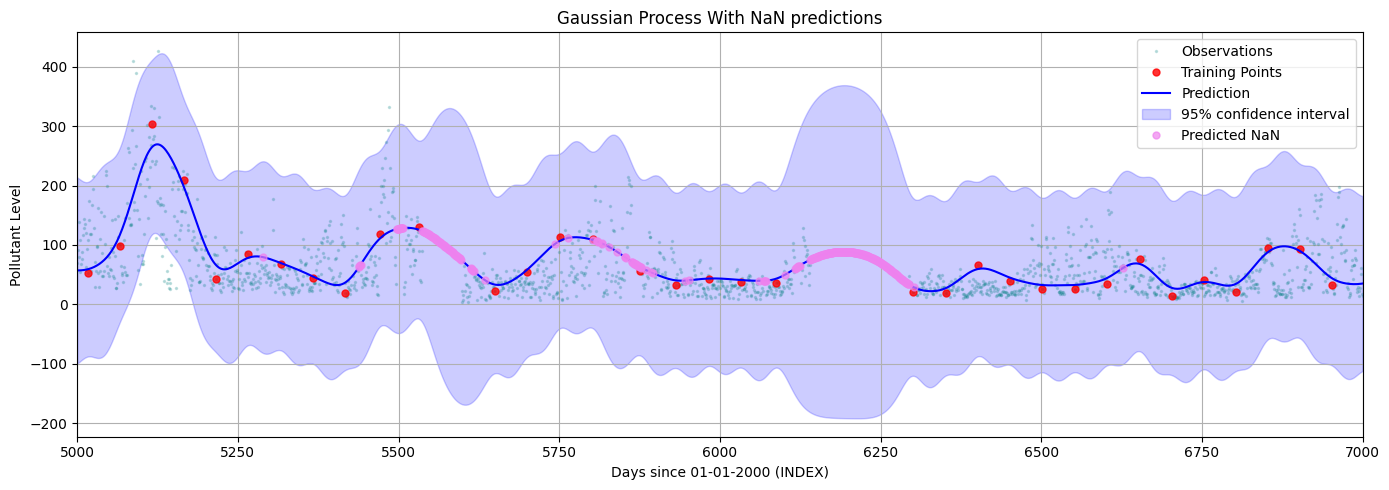

In [203]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process With NaN predictions", X_nan=X_nan, focus=(5000, 7000))

Y finalmente realizamos una predicción a futuro:

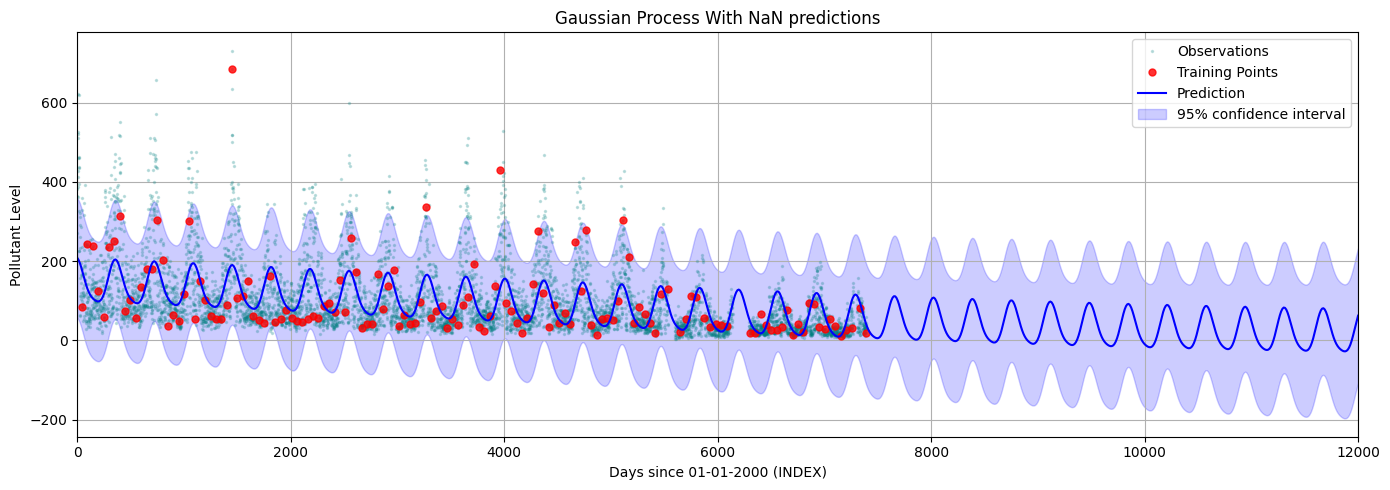

In [210]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process With NaN predictions", focus=(0, 12000), future_pred_length=6000)

Aquí concluimos:
- La predicción a futuro en un rango fuera del de los datos depende mucho del kernel obtenido.
- En nuestro caso, como en el futuro no hay datos, cuando la predicción es muy lejana, los datos dejan de tener efecto a las predicciones, haciendo que se mantenga una tendencia periódica estática.

# c) Optimiza el Kernel (sus hipérparámetros)

In [216]:
# dataset a ajustar por Gaussian Process:
X, y, X_nan = get_station_series(final_data, station_id)


trained_mask = list(range(0, len(X), 50))  # Mask for training data

X_subset = X[trained_mask]  # Subset for plotting
y_subset = y[trained_mask]


kernel = ConstantKernel(2)*RationalQuadratic(length_scale=40, alpha=1.0) \
       +  WhiteKernel(noise_level=0.3) +  \
        ExpSineSquared(length_scale=10.0, periodicity=365.0, periodicity_bounds="fixed")

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=0.1, normalize_y=True, random_state=10)
gp.fit(X_subset.reshape(-1, 1), y_subset)

gp.kernel_

1.16**2 * RationalQuadratic(alpha=1.97e+03, length_scale=1.12e+04) + WhiteKernel(noise_level=0.606) + ExpSineSquared(length_scale=2.24, periodicity=365)

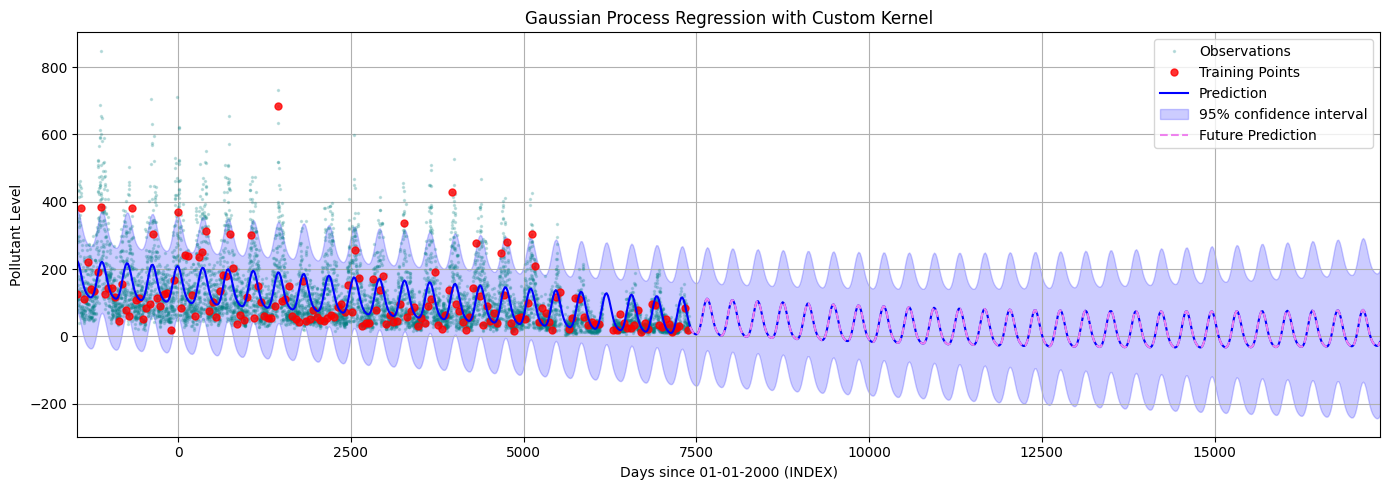

In [217]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process Regression with Custom Kernel", future_pred_length=10000)

Como conclusiones:
- Al optimizar se ha dado más peso a la parte periódica del kernel.
- Se puede ver una tendencia fija de un año se adapta muy bien al modelo.
- La parte de RationalQuadratic está detectando una tencendia decreciente para los años posteriores.

Ahora vamos a probar con un nuevo contaminante

   station  num_NA    average    max  min  q005  q095
0       08     620  39.797015  107.0  1.0   8.0  76.0
1       16     150  45.965013  120.0  1.0  10.0  83.0
2       17    1611  43.214704  112.0  1.0   8.0  81.0
3       18     152  46.264840  118.0  1.0   7.0  85.0
4       24     160  53.724915  148.0  1.0  10.0  93.0
5       27    3311  49.960762  121.0  1.0   9.7  86.0
6       35     225  42.724412  110.0  1.0   7.0  80.0
7       39     190  47.279430  121.0  1.0   9.0  85.0
8       49    3320  49.724858  112.0  1.0   8.0  85.0
9       54    3312  51.564704  123.0  2.0  12.0  87.0
10      58    3300  54.830679  134.0  2.0  13.0  92.0
11      59    3311  55.405835  124.0  1.0  15.0  92.0
12      60    3349  57.149302  126.0  2.0  14.0  95.0
13      56    4877  41.675450   99.0  1.0   8.3  75.0


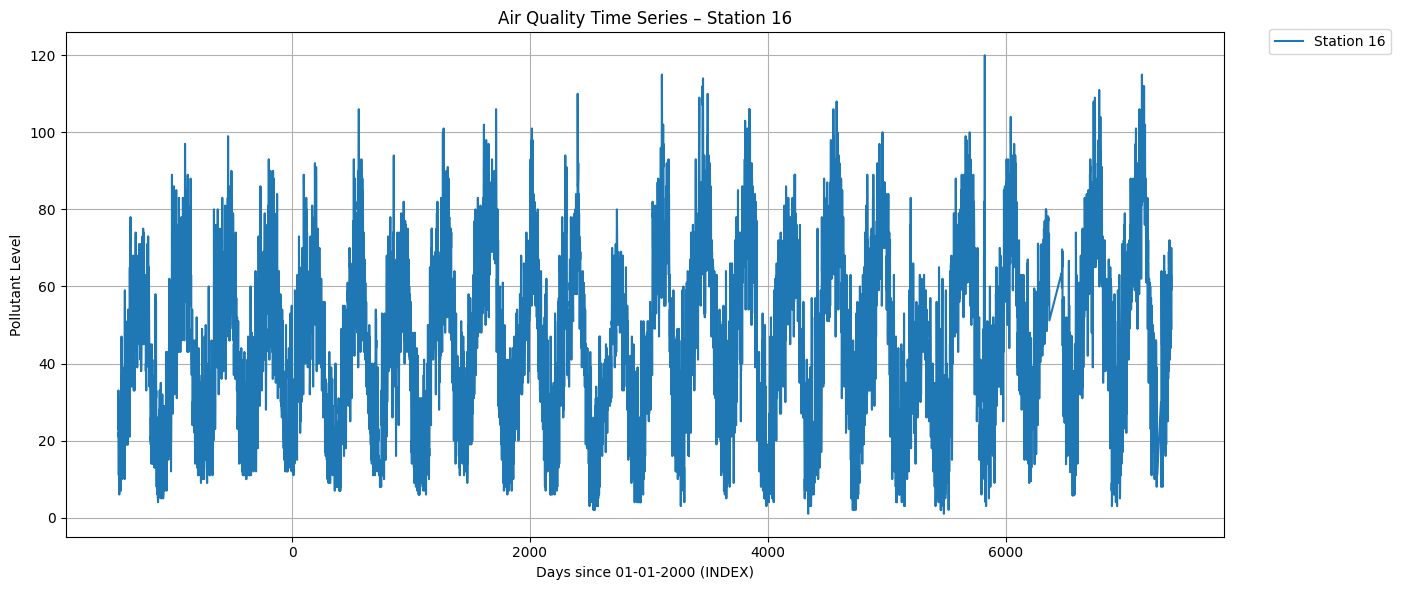

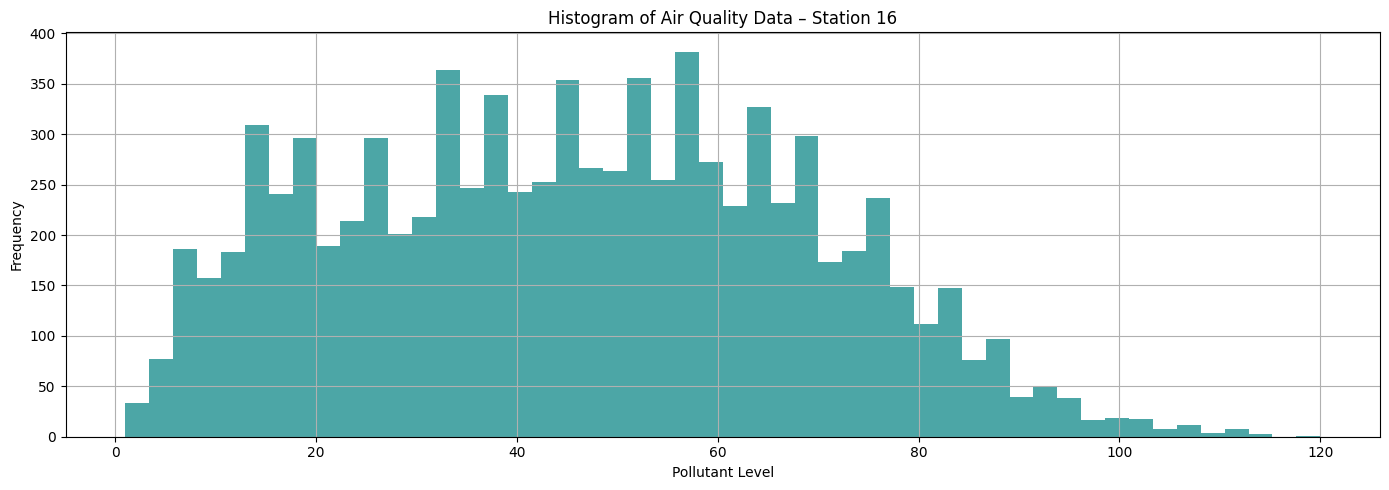

In [235]:
contaminant="O3"
final_data = parse_multiple_files(file_list, contaminant_name_to_code[contaminant])

# Check the data statistics  and plot the time series
summary_table = summarize_station_data(final_data)
print(summary_table)

# Pick a station with data
station_id = "16"
plot_station_time_series(final_data, station_id)

# Plot the histogram of the data for the selected station
histogram_station_data(final_data, station_id)

# Plot the monthly data for the selected station
monthly_data = get_station_monthly_data(final_data, station_id)



## Ozono ($O_3$)

Ahora vamos a realizar un ajuste similar utilizando la covariable `O3` que representa la cantidad de Ozono en aire ($\mu g/m^3$) ya que:
- Se está detectando una tendencia creciente
- Hay menores valores atípicos

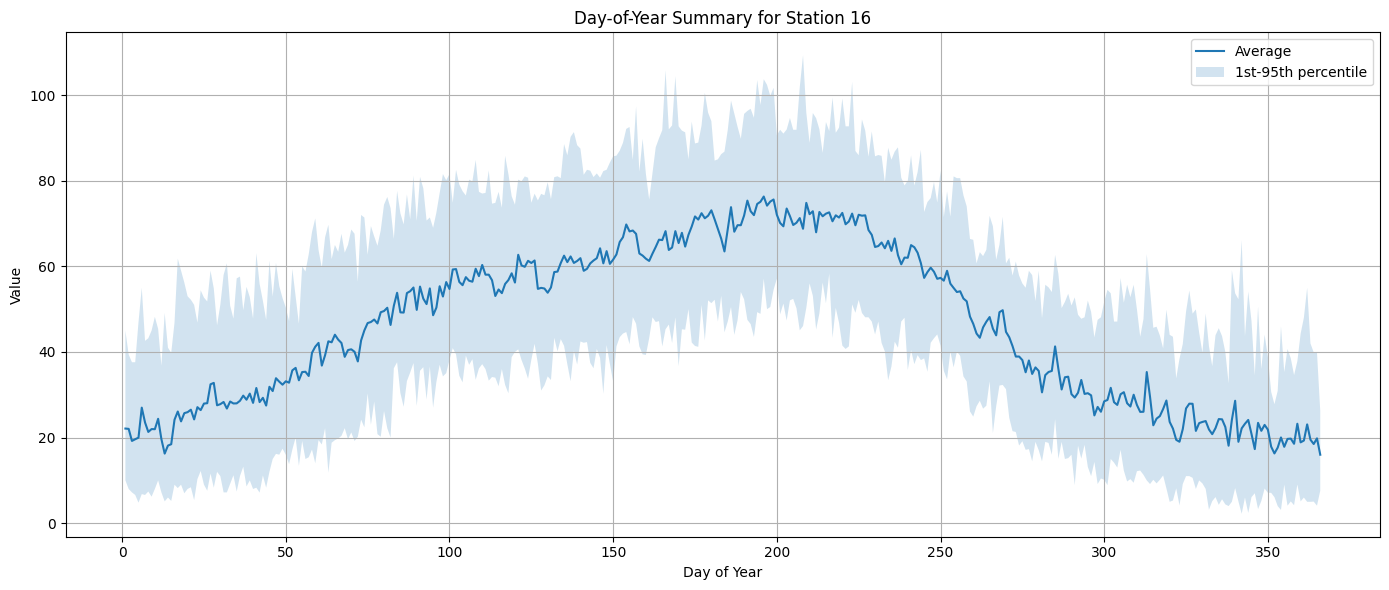

In [236]:
days_summary = get_station_dayofyear_data(final_data, station_id)
plot_dayofyear_summary(days_summary, station_id)

Aquí podemos ver:
- Tendencia contraria al anterior debido a que la luz solar favorece la emisión de este gas
- Tendencia cíclica bastante bien definida.

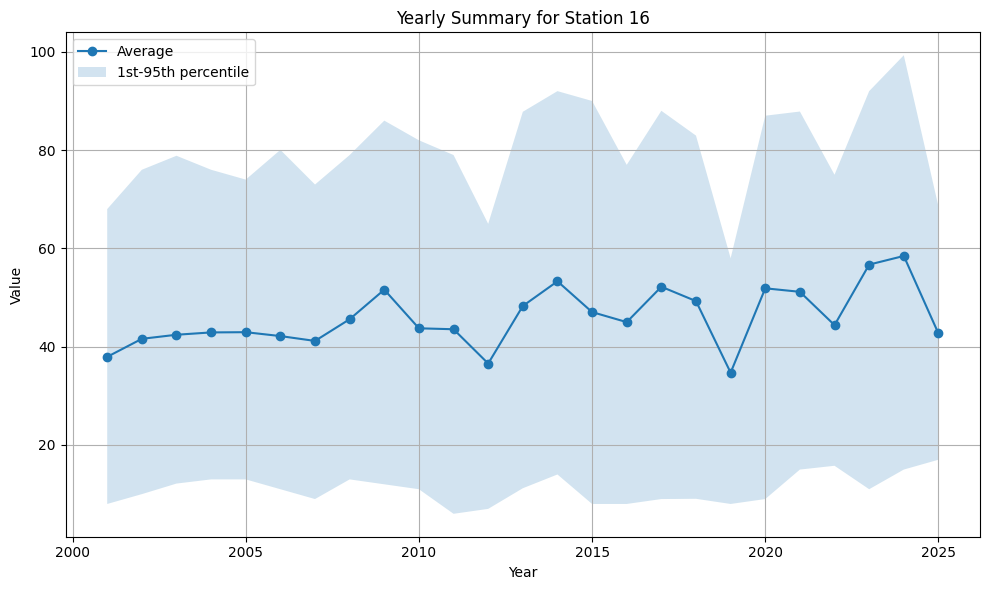

In [237]:
year_summary = get_station_yearly_data(final_data, station_id)
plot_yearly_summary(year_summary, station_id)

En cuestión de años:
- Se aprecia una ligera tendencia creciente, con picos en diferentes años, que pueden coincidir con años más/menos calurosos.

Por todo esto, diseñamos un kernel similar al anterior con:
- Menor nivel de ruido.
- Más importancia a la parte periódica:

In [251]:
# dataset a ajustar por Gaussian Process:
X, y, X_nan = get_station_series(final_data, station_id)


trained_mask = list(range(0, len(X), 10))  # Mask for training data

X_subset = X[trained_mask]  # Subset for plotting
y_subset = y[trained_mask]


kernel = ConstantKernel(0.5)*RationalQuadratic(length_scale=40, alpha=1.0) \
       +  WhiteKernel(noise_level=0.2) +  \
        ExpSineSquared(length_scale=30.0, periodicity=365.0, periodicity_bounds="fixed")

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=0.1, normalize_y=True, random_state=10, optimizer=None)
gp.fit(X_subset.reshape(-1, 1), y_subset)

gp.kernel_

0.707**2 * RationalQuadratic(alpha=1, length_scale=40) + WhiteKernel(noise_level=0.2) + ExpSineSquared(length_scale=30, periodicity=365)

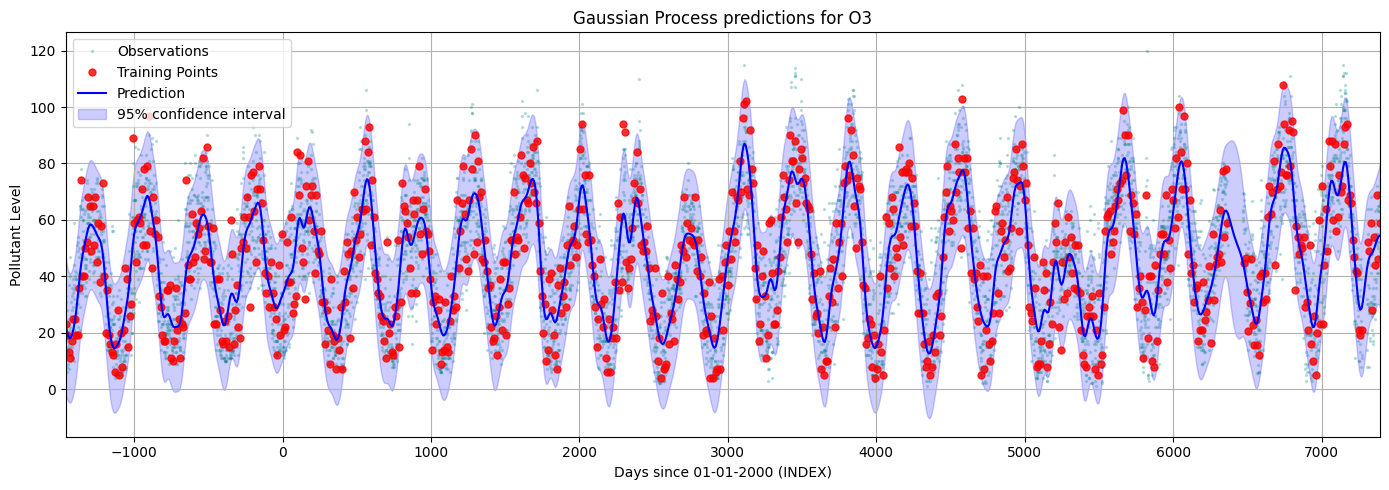

In [253]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process predictions for O3")

Aquí podemos ver:
- Una clara tendencia cíclica
- Un modelo sin optimización, se ha ajustando bastante bien a los datos.

Vamos a ver el modelo optimizado

In [257]:
# dataset a ajustar por Gaussian Process:
X, y, X_nan = get_station_series(final_data, station_id)


trained_mask = list(range(0, len(X), 50))  # Mask for training data

X_subset = X[trained_mask]  # Subset for plotting
y_subset = y[trained_mask]


kernel = RationalQuadratic(length_scale=40, alpha=1.0) \
       +  WhiteKernel(noise_level=0.2) +  \
        ExpSineSquared(length_scale=50.0, periodicity=365.0, periodicity_bounds="fixed")

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=0.1, normalize_y=True, random_state=10, optimizer="fmin_l_bfgs_b")
gp.fit(X_subset.reshape(-1, 1), y_subset)

gp.kernel_

RationalQuadratic(alpha=9.51, length_scale=9.01e+04) + WhiteKernel(noise_level=0.305) + ExpSineSquared(length_scale=1.31, periodicity=365)

Predicting 150 NaN points within focus range


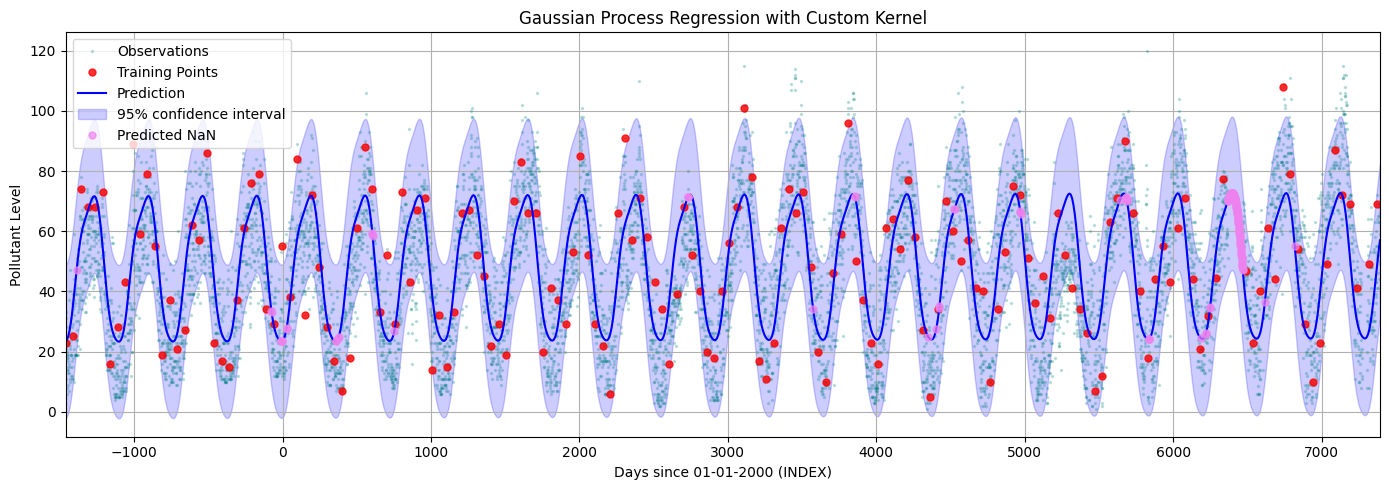

In [266]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process Regression with Custom Kernel", X_nan=X_nan)

Predicting 109 NaN points within focus range


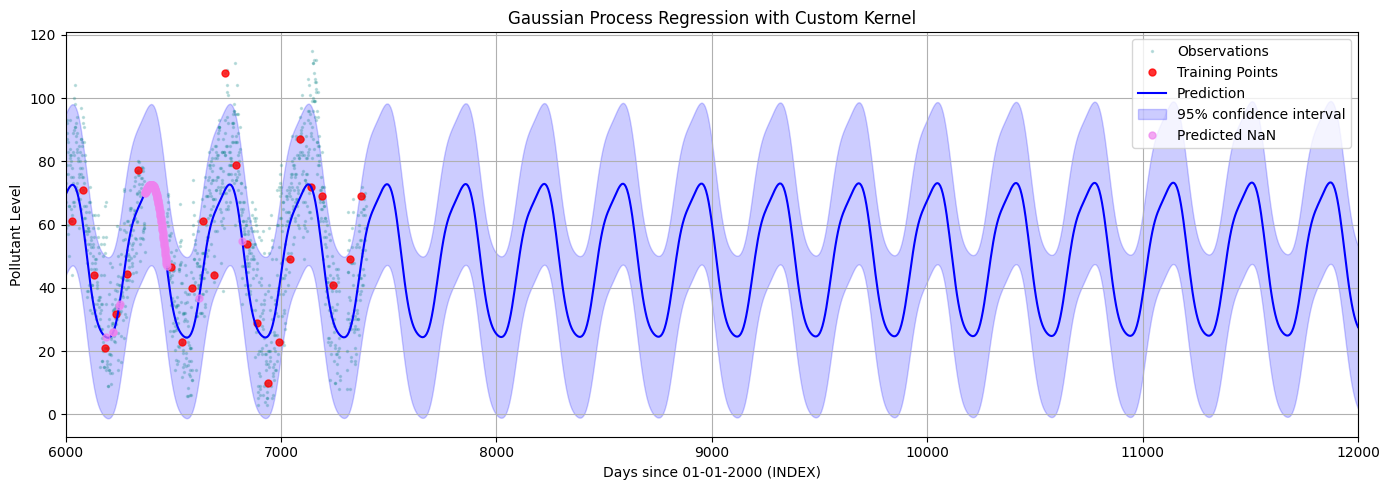

In [267]:
plot_gp(gp, X, y, trained_mask=trained_mask, title="Gaussian Process Regression with Custom Kernel", future_pred_length=200000, focus=(6000, 12000), X_nan=X_nan)

En cuanto a las predicciones:
- Nuestro modelo no detecta un impacto ni creciente ni decreciente en las concentraciones de Ozono en esta estación.